# Tuần 01 — Câu hỏi và dữ liệu

**UET.MAT1052 — Xác suất thống kê**

BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

---

Trước khi tính bất kỳ con số nào, cần trả lời hai câu: dữ liệu này ghi lại cái gì, và nó cho phép ta nói đến đâu. Cả khóa học sẽ quay lại hai câu này nhiều lần. Tuần này ta tập đặt chúng thật cụ thể.

Sau buổi học, bạn cần làm được năm việc:

1. Đọc một câu kết luận và xếp nó vào một trong bốn loại: tóm tắt, tổng quát hóa, khẳng định nhân quả, dự đoán. Giải thích dựa vào việc câu đó nói về ai và muốn làm gì, không dựa vào từ khóa.
2. Mở một bảng dữ liệu và chỉ ra đơn vị quan sát, các biến, các giá trị.
3. Xếp loại một biến dựa trên ý nghĩa của giá trị, và nhận ra khi kiểu lưu trữ trong phần mềm (dtype) dẫn ta đi sai.
4. Chọn mỗi hàng nên đại diện cho cái gì để trả lời một câu hỏi, và nói được thông tin nào mất đi khi gộp dữ liệu.
5. Phân biệt số hàng của bảng với số đơn vị độc lập.

**Cách dùng notebook.** Đọc từ trên xuống và chạy lần lượt từng ô (hoặc *Kernel → Restart & Run All*). Ở các câu hỏi, hãy tự trả lời trước rồi mới mở phần đáp án thu gọn. Những ô ghi "Thử thay đổi" là chỗ bạn nên sửa tham số và chạy lại.

Mã câu hỏi (W01-Q01, W01-CH02, ...) giữ nguyên như bài giảng trên lớp.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
rng = np.random.default_rng(42)   # cố định để ai chạy cũng ra cùng kết quả

DATA = "datasets/"

---
## Phần 1. Từ câu hỏi đến khẳng định

### 1.1 Cùng một con số, hai câu nói khác nhau

Trong một khảo sát ở lớp STAT 20 (Berkeley), sinh viên được hỏi trước khi vào môn họ đã từng viết code chưa. Trong số những người trả lời, 70% nói chưa. Giả sử đó là tất cả những gì ta biết.

> **W01-Q01.** Hai câu sau khác nhau ở đâu? Câu nào nói nhiều hơn những gì dữ liệu cho thấy?
>
> (1) "70% người trả lời khảo sát chưa có kinh nghiệm viết code."
> (2) "70% sinh viên Berkeley chưa có kinh nghiệm viết code."

<details><summary>Đáp án</summary>

Câu (1) chỉ nói về những người đã trả lời, tức là đúng những người có trong dữ liệu. Đó là một **tóm tắt**.

Câu (2) nói về toàn bộ sinh viên Berkeley, một nhóm lớn hơn nhiều so với số người đã trả lời. Đó là một **tổng quát hóa**. Nó có thể đúng hoặc sai, tùy vào việc những người trả lời có giống phần còn lại hay không, và bảng số liệu không tự trả lời được điều đó.

Con số 70% giống hệt nhau. Thứ khác nhau là câu nói đang áp dụng con số ấy cho ai.
</details>

### 1.2 Dữ liệu có trước bảng

<img src="figures/stat20_vong_doi_khoa_hoc_du_lieu.png" width="560">

*Hình 1.1. Vòng lặp giữa thế giới và dữ liệu: đặt câu hỏi về thế giới để đi tới dữ liệu (Ask a question), rồi dùng dữ liệu để đưa ra khẳng định giúp hiểu thế giới (Make a claim). Nguồn hình: STAT 20 (UC Berkeley), bản dịch tiếng Việt, §1.2.*

Người làm việc với dữ liệu thường xuất phát từ một trong hai đầu của vòng này: có sẵn một câu hỏi và đi tìm dữ liệu, hoặc có sẵn một bộ dữ liệu và đi tìm câu hỏi đáng trả lời. Tuần này đi theo chiều từ câu hỏi đến dữ liệu, rồi từ dữ liệu quay về một khẳng định.

Một bảng dữ liệu không tự nhiên mà có. Trước khi có bảng, ai đó đã quyết định: đo ai hoặc đo cái gì, đo bằng cách nào, đo mấy lần, có tác động gì vào đối tượng hay chỉ đứng ngoài ghi lại, và có gộp số liệu lại trước khi đưa cho ta hay không. Tập hợp các quyết định đó gọi là **quá trình tạo dữ liệu**.

Có thể hình dung một phân tích đi theo thứ tự:

câu hỏi, rồi chọn đơn vị và biến cần đo, rồi quá trình tạo dữ liệu, rồi dữ liệu, rồi phân tích, cuối cùng là một khẳng định.

Khi đọc kết luận của người khác, ta đi ngược lại: kết luận này cần loại dữ liệu nào, được thu thập ra sao, thì mới đứng vững?

### 1.3 Bốn loại khẳng định

| Loại | Câu đó muốn làm gì | Mẫu câu thường gặp |
|---|---|---|
| **Tóm tắt** (summary) | Mô tả chính dữ liệu đang có | "Trong dữ liệu này, ..." |
| **Tổng quát hóa** (generalization) | Nói về một nhóm đơn vị lớn hơn nhóm đã quan sát | "Trong toàn bộ tổng thể ..., ..." |
| **Khẳng định nhân quả** (causal claim) | Nói rằng thay đổi một biến sẽ làm biến khác thay đổi | "Nếu ta thay đổi X thì Y sẽ ..." |
| **Dự đoán** (prediction) | Đoán một giá trị chưa biết từ các biến đã biết | "Biết X của trường hợp mới, ta đoán Y là ..." |

<img src="figures/stat20_bon_loai_khang_dinh.png" width="480">

*Hình 1.2. Mục tiêu của khóa học: học cách phản biện và xây dựng các khẳng định dựa trên dữ liệu. Các biểu tượng nhỏ gợi ý công cụ đi kèm mỗi loại: bảng, trung bình và biểu đồ cho tóm tắt; một mẫu nhỏ và một tổng thể lớn cho tổng quát hóa; A → B cho nhân quả; một đường xu hướng kéo dài cho dự đoán. Nguồn hình: STAT 20, bản dịch tiếng Việt, §1.1.1.*

Đừng phân loại bằng cách dò từ khóa. Hãy hỏi ba câu: kết luận này nói về ai hoặc cái gì? Nó có nói tới việc can thiệp, thay đổi một thứ gì đó không? Có giá trị nào đang chưa biết mà câu muốn đoán không?

Về mức độ khó: tóm tắt chỉ cần số liệu được đo và xử lý đúng. Tổng quát hóa cần biết dữ liệu được lấy từ tổng thể như thế nào (Tuần 09). Nhân quả cần một thiết kế tách được tác động của biến đang xét khỏi các yếu tố khác (Tuần 12–13). Dự đoán cần kiểm tra trên các trường hợp mới (Tuần 14–15).

### 1.4 Khi câu nói về quan hệ giữa hai biến

Bốn loại ở trên là khung chính. Riêng với các câu nói về hai biến, ví dụ nhiệt độ máy chủ và độ trễ mạng, nên tách thành hai câu hỏi riêng.

Thứ nhất là **phạm vi**: câu đang mô tả dữ liệu đã quan sát, hay đang mở rộng ra ngoài?

Thứ hai là **vai trò của quan hệ**: câu chỉ nói hai biến hay đi cùng nhau, hay dùng biến này để đoán biến kia, hay nói biến này làm thay đổi biến kia?

Ba câu dưới đây dùng đúng hai cột `temperature` và `latency` nhưng nói ba điều khác nhau:

- "Trong log đã ghi, những lúc nhiệt độ cao thì độ trễ cũng thường cao hơn." Đây là mô tả một mối liên hệ trong dữ liệu.
- "Biết nhiệt độ lúc này, ta đoán độ trễ của lần chạy tới." Đây là dự đoán.
- "Tăng nhiệt độ lên thì độ trễ sẽ tăng." Đây là nhân quả.

Câu thứ nhất có thể đúng mà câu thứ ba vẫn sai: ví dụ khi máy chủ tải nặng thì vừa nóng lên vừa chậm đi, còn nhiệt độ tự nó không làm chậm gì cả. Lưu ý thêm: "mối liên hệ" không phải loại khẳng định thứ năm. Một câu về mối liên hệ vẫn là tóm tắt hoặc tổng quát hóa, tùy phạm vi của nó.

> **W01-Q02.** Xếp mỗi câu vào một trong bốn loại. Chỉ dựa vào những gì câu chữ cho biết, không tự giả định thêm về cách lấy mẫu.
>
> A. "Trong tập dữ liệu đang có, `species` nhận ba giá trị Adelie, Chinstrap, Gentoo."
> B. "Từ khảo sát lớp, ta kết luận 70% sinh viên Berkeley chưa có kinh nghiệm viết code."
> C. "Dùng thuốc mới làm thay đổi khả năng khỏi bệnh."
> D. "Từ các thông tin đã biết, ta đoán điểm bài kiểm tra của một sinh viên chưa có điểm."

<details><summary>Đáp án</summary>

- A là tóm tắt: chỉ mô tả tập dữ liệu đang có.
- B là tổng quát hóa: đi từ những người trả lời khảo sát sang toàn bộ sinh viên Berkeley.
- C là khẳng định nhân quả: nói việc dùng thuốc làm kết quả thay đổi.
- D là dự đoán: thứ cần tìm là điểm của một sinh viên cụ thể mà ta chưa biết.

Chỗ dễ nhầm là B và D, vì cả hai đều dùng dữ liệu cũ để nói về điều chưa quan sát. Câu kế tiếp làm rõ sự khác nhau.
</details>

> **W01-CH01.** Một thành phố muốn biết tình hình kết nối Internet của các hộ dân.
> Nhóm A khảo sát một số hộ rồi ước tính tỉ lệ hộ có Internet trên toàn thành phố.
> Nhóm B dùng đặc điểm của các hộ đã khảo sát để đoán xem một hộ mới cụ thể có Internet hay không.
> Cả hai nhóm đều dùng dữ liệu đã có để nói về điều chưa quan sát. Vì sao đây vẫn là hai loại khẳng định khác nhau?

<details><summary>Đáp án</summary>

Nhóm A muốn biết một con số mô tả **cả tổng thể** (tỉ lệ hộ có Internet trong thành phố). Đó là tổng quát hóa.

Nhóm B muốn biết **giá trị của một hộ cụ thể**. Đó là dự đoán.

Cách phân biệt: kết quả cuối cùng là một đặc điểm của cả nhóm lớn, hay là giá trị chưa biết của một đơn vị? Chuyện "hiện tại hay tương lai" không quyết định: dự đoán có thể về một hộ đang tồn tại ngay lúc này.
</details>

### 1.5 Làm với dữ liệu thật: tên thú cưng ở Seattle

Thành phố Seattle công khai danh sách giấy phép nuôi thú cưng. Mỗi bản ghi có tên con vật và loài. OpenIntro dùng dữ liệu này để so sánh tên phổ biến ở chó và mèo.

Trước khi chạy ô dưới, hãy đoán: một hàng trong bảng này là gì?

In [2]:
pets = pd.read_csv(DATA + "seattlepets.csv")
pets.head()

,license_issue_date,animal_name,species
0,2018-11-16,Wall-E,Dog
1,2018-11-11,Andre,Dog
2,2018-11-21,Mac,Dog
3,2018-11-23,Melb,Cat
4,2018-12-30,Gingersnap,Cat


In [3]:
print("Số hàng, số cột:", pets.shape)
pets["species"].value_counts()

Số hàng, số cột: (52519, 3)


species
Dog     35181
Cat     17294
Goat       38
Pig         6
Name: count, dtype: int64

Bảng có hơn 52 nghìn hàng; phần lớn là chó và mèo, có vài chục con dê và lợn. Giờ xem 5 tên phổ biến nhất ở mỗi loài.

In [4]:
for loai in ["Dog", "Cat"]:
    ten = pets.loc[pets["species"] == loai, "animal_name"]
    print(loai)
    print(ten.value_counts().head(5))
    print()

Dog
animal_name
Lucy       337
Charlie    306
Bella      249
Luna       244
Daisy      221
Name: count, dtype: int64

Cat
animal_name
Luna     111
Lucy     102
Lily      86
Max       83
Bella     82
Name: count, dtype: int64



> **W01-OI01.**
> 1. Đơn vị quan sát là gì?
> 2. `animal_name` và `species` là loại biến gì?
> 3. Câu "Trong dữ liệu giấy phép, tên Lucy phổ biến ở chó hơn ở mèo" là loại khẳng định nào?
> 4. Câu "Dữ liệu này phản ánh tất cả thú cưng ở Seattle" đi xa hơn dữ liệu ở chỗ nào? Nêu một lý do cần cẩn thận.

<details><summary>Đáp án</summary>

1. Một thú cưng đã được cấp giấy phép ở Seattle (đúng hơn là một giấy phép, vì cùng một con có thể được gia hạn).
2. Cả hai là biến phân loại danh nghĩa: giá trị là nhãn, không có độ lớn và không có thứ tự tự nhiên.
3. Tóm tắt, vì câu chỉ nói về các bản ghi đang có. (Để ý chó nhiều gấp đôi mèo, nên so 337 với 102 chưa công bằng. Tính theo tỉ lệ trong từng loài thì Lucy chiếm khoảng 0,96% số chó và 0,59% số mèo, câu vẫn đúng. Tuần 02 sẽ bàn kỹ chuyện chọn mẫu số.)
4. Đây là tổng quát hóa từ "thú cưng có đăng ký" sang "mọi thú cưng ở Seattle". Những con không đăng ký không có mặt trong dữ liệu, và chúng có thể khác những con được đăng ký (ví dụ mèo nuôi trong nhà ít được đăng ký hơn chó phải dắt ra đường). Trước khi mở rộng một kết luận, hãy hỏi ai có mặt trong dữ liệu và ai bị bỏ ra ngoài.
</details>

> **W01-OI02.** Khảo sát Xã hội Tổng quát (GSS) hỏi một mẫu ngẫu nhiên 1.155 người Mỹ: "Sau một ngày làm việc bình thường, bạn có khoảng bao nhiêu giờ để thư giãn hoặc làm việc mình thích?" Trung bình trong mẫu là 1,65 giờ.
> 1. Đơn vị quan sát là gì?
> 2. Biến được đo là gì, thuộc loại nào?
> 3. "Trong 1.155 người trả lời, trung bình là 1,65 giờ" là loại khẳng định nào?
> 4. "Người Mỹ trung bình có 1,65 giờ thư giãn mỗi ngày làm việc" là loại nào?
>
> *(Chuyển thể từ OpenIntro Statistics 4e, bài 1.17.)*

<details><summary>Đáp án</summary>

1. Một người trả lời khảo sát.
2. Số giờ thư giãn sau ngày làm việc. Về mặt khái niệm đây là biến số liên tục.
3. Tóm tắt.
4. Tổng quát hóa. Việc mẫu được chọn ngẫu nhiên cho ta cơ sở tốt hơn để làm việc này; còn tổng quát hóa sai lệch bao nhiêu thì Tuần 09–10 mới đo được.
</details>

---
## Phần 2. Từ đối tượng đến biến

### 2.1 Đơn vị quan sát, biến, giá trị

Ba khái niệm này luôn đi cùng nhau.

- **Đơn vị quan sát** là loại đối tượng mà ta ghi thông tin trên đó: một sinh viên, một khoản vay, một thư điện tử, một lượt đo.
- **Biến** là một đặc điểm của đơn vị quan sát mà ta có thể đo hoặc ghi lại, ví dụ `nganh_hoc`.
- **Giá trị** là kết quả cụ thể của biến trên một đơn vị, ví dụ `"Khoa học máy tính"`.

Đơn vị quan sát không phải lúc nào cũng là "một người". Trong bảng điểm của phòng đào tạo, một hàng là một lần một sinh viên học một môn trong một học kỳ. Phần 3 sẽ quay lại chuyện này.

### 2.2 Hai nhóm biến lớn

Khóa học chia biến thành hai nhóm: biến số và biến phân loại. Trong giáo trình tiếng Việt khác, bạn sẽ gặp tên *biến số* và *biến phân loại*; tài liệu tiếng Anh gọi là *numerical* và *categorical*. Các cặp tên này chỉ cùng một thứ.

- **Biến số** (numerical; còn gọi là biến số): giá trị là số và độ lớn của số có ý nghĩa, cộng trừ so sánh được.
  - *Liên tục*: về nguyên tắc có thể nhận mọi giá trị trong một khoảng, như nhiệt độ, chiều dài, lãi suất.
  - *Rời rạc*: nhận các giá trị tách rời, thường là số đếm, như số người trong hộ.
- **Biến phân loại** (categorical; còn gọi là biến phân loại): giá trị là các mức (nhóm).
  - *Danh nghĩa* (nominal): các mức không có thứ tự, như loài, bang, ngành học.
  - *Thứ bậc* (ordinal): các mức có thứ tự tự nhiên, như trình độ học vấn, mức độ đồng ý.

Sơ đồ phân loại này (Hình 1.3) được vẽ lại bằng code dưới đây.

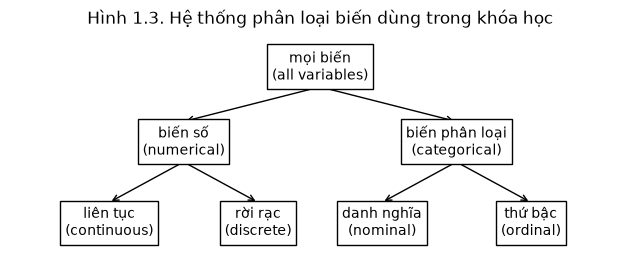

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

o = {"all": (5, 3.4), "num": (2.8, 2.1), "cat": (7.2, 2.1),
     "cont": (1.6, 0.7), "disc": (4.0, 0.7), "nom": (6.0, 0.7), "ord": (8.4, 0.7)}
nhan = {"all": "mọi biến\n(all variables)", "num": "biến số\n(numerical)", "cat": "biến phân loại\n(categorical)",
        "cont": "liên tục\n(continuous)", "disc": "rời rạc\n(discrete)",
        "nom": "danh nghĩa\n(nominal)", "ord": "thứ bậc\n(ordinal)"}
for cha, con in [("all", "num"), ("all", "cat"), ("num", "cont"), ("num", "disc"), ("cat", "nom"), ("cat", "ord")]:
    ax.annotate("", xy=(o[con][0], o[con][1] + 0.35), xytext=(o[cha][0], o[cha][1] - 0.35),
                arrowprops=dict(arrowstyle="->", color="black"))
for k, (x0, y0) in o.items():
    ax.text(x0, y0, nhan[k], ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="square,pad=0.35", facecolor="white", edgecolor="black"))
ax.set_title("Hình 1.3. Hệ thống phân loại biến dùng trong khóa học")
plt.show()

Chỗ hay nhầm: một cột chứa toàn chữ số chưa chắc là biến số. Mã sinh viên `24001234` là số nhưng chỉ dùng để gọi tên; lấy trung bình mã sinh viên không cho ta biết gì. Thang đánh giá 1–5 cũng là số, nhưng khoảng cách từ "1 = rất không hài lòng" lên "2" chưa chắc bằng khoảng cách từ "4" lên "5".

Ô dưới minh họa: phần mềm vẫn tính trung bình mã sinh viên cho bạn, không hề báo lỗi.

In [6]:
ma_sinh_vien = pd.Series([24001234, 24005678, 23009911, 24000102])
print("dtype:", ma_sinh_vien.dtype)
print("Trung bình mã sinh viên:", ma_sinh_vien.mean())

dtype: int64
Trung bình mã sinh viên: 23754231.25


Con số trên đúng về mặt tính toán nhưng vô nghĩa về mặt thống kê. Máy tính không biết cột này dùng để làm gì; chỉ người phân tích biết.

> **W01-CH02.** Bạn nhận một file chỉ có một cột `x`, không có tài liệu mô tả. Các giá trị là 1, 2, 3, 4, 5. Phần mềm báo cột lưu dạng số nguyên.
> 1. Có đủ thông tin để kết luận `x` là biến số rời rạc không?
> 2. Nghĩ ra hai tình huống thực tế cùng dùng 1–5 nhưng là hai loại biến khác nhau.
> 3. Nếu phần mềm báo `dtype = int64`, câu trả lời có thay đổi không?

<details><summary>Đáp án</summary>

1. Không đủ. Cách viết bằng chữ số không quyết định loại biến.
2. Nếu 1–5 là số lỗi tìm thấy trong một bài kiểm thử phần mềm, đó là biến số rời rạc. Nếu 1–5 là mức từ "rất không đồng ý" đến "rất đồng ý", đó là biến phân loại thứ bậc.
3. Không. `int64` chỉ nói máy lưu cột này như thế nào. Nó không nói phép cộng trừ trên các giá trị có nghĩa hay không.
</details>

### 2.3 Vì sao phải phân loại biến?

Loại biến quyết định gần như mọi bước sau: ghi dữ liệu theo đơn vị đo hay theo nhóm, vẽ biểu đồ gì, tóm tắt bằng phép tính nào, đưa vào mô hình ra sao. Tuần 01 chỉ dựng hệ thống phân loại; Tuần 02–04 dùng nó để chọn cách tóm tắt.

---
## Phần 3. Từ biến đến data frame

### 3.1 Data frame

**Data frame** (bảng dữ liệu dạng hàng–cột) là cách sắp xếp quen thuộc nhất: mỗi hàng là một quan sát, mỗi cột là một biến, mỗi ô là giá trị của một biến trên một quan sát.

Khi gặp một bảng mới, câu đầu tiên nên hỏi là **mỗi hàng đại diện cho cái gì**. Chưa trả lời được câu này thì chưa hiểu bảng.

**Data frame không phải là "bảng tính bất kỳ".** Xem bảng dưới đây, ghi số lần người ta báo cáo nhìn thấy người ngoài hành tinh, theo màu da và theo thời điểm nhìn thấy.

<img src="figures/stat20_bang_nguoi_ngoai_hanh_tinh.png" width="330">

*Hình 1.4. Một bảng liên hợp: số lần nhìn thấy người ngoài hành tinh theo màu (xanh lá, xanh dương) và thời điểm (đêm, ngày). Nguồn hình: STAT 20, bản dịch tiếng Việt, §1.2.3.*

Bảng này gọn và dễ đọc, nhưng nó **không phải một data frame**. Hàng "Night" không phải một lần nhìn thấy, cột "Green" không phải một biến, và ô 55 không phải giá trị của một biến trên một quan sát. Nó là kết quả *đếm* sau khi đã gộp dữ liệu. Muốn có data frame, phải quay về mức từng lần nhìn thấy: mỗi hàng là một lần, với hai biến `mau` và `thoi_diem`. Ô dưới dựng lại data frame 144 hàng đó từ bảng đếm, rồi đếm ngược lại để kiểm tra.

In [7]:
dem = {("Xanh lá", "Đêm"): 55, ("Xanh dương", "Đêm"): 11,
       ("Xanh lá", "Ngày"): 23, ("Xanh dương", "Ngày"): 55}

cac_hang = []
for (mau, thoi_diem), so_lan in dem.items():
    for _ in range(so_lan):
        cac_hang.append({"mau": mau, "thoi_diem": thoi_diem})
nhin_thay = pd.DataFrame(cac_hang)

print("Data frame có shape:", nhin_thay.shape, "  (mỗi hàng là một lần nhìn thấy)")
print(nhin_thay.sample(5, random_state=1), "\n")
print(pd.crosstab(nhin_thay["thoi_diem"], nhin_thay["mau"], margins=True))

Data frame có shape: (144, 2)   (mỗi hàng là một lần nhìn thấy)
           mau thoi_diem
94  Xanh dương      Ngày
91  Xanh dương      Ngày
84     Xanh lá      Ngày
48     Xanh lá       Đêm
53     Xanh lá       Đêm 

mau        Xanh dương  Xanh lá  All
thoi_diem                          
Ngày               55       23   78
Đêm                11       55   66
All                66       78  144


Đi từ data frame sang bảng đếm thì dễ: chỉ cần đếm. Đi ngược lại chỉ làm được vì bảng này chỉ có hai biến. Nếu bản gốc còn ghi thêm địa điểm hay người báo cáo, bảng đếm đã làm mất những thông tin đó, và không cách nào dựng lại được. Tuần 02 sẽ học cách đọc loại bảng này.

### 3.2 Ví dụ: `email50`

Bộ `email50` của OpenIntro gồm 50 thư điện tử và 21 biến. Ở đây ta chưa làm bộ lọc thư rác; chỉ tập đọc cấu trúc.

In [8]:
email50 = pd.read_csv(DATA + "email50.csv")
print(email50.shape)
email50[["spam", "cc", "image", "number"]].head(8)

(50, 21)


,spam,cc,image,number
0,0,0,0.0,small
1,0,0,0.0,big
2,1,4,0.0,none
3,0,0,0.0,small
4,0,0,0.0,small
5,0,0,0.0,small
6,0,0,0.0,small
7,0,0,0.0,small


Ý nghĩa bốn biến:

| Biến | Ý nghĩa |
|---|---|
| `spam` | 1 nếu thư là thư rác, 0 nếu không |
| `cc` | số người được gửi kèm bản sao |
| `image` | số ảnh đính kèm |
| `number` | thư không chứa số (`none`), chỉ có số nhỏ (`small`), hay có số lớn (`big`) |

> **W01-EX01.**
> 1. Đơn vị quan sát là gì?
> 2. Xếp loại bốn biến trên.
> 3. Vì sao không thể xếp loại `number` chỉ nhìn vào tên cột?

Sau khi tự trả lời, chạy ô dưới để xem pandas lưu các cột này thế nào, rồi so với câu trả lời của bạn.

In [9]:
email50[["spam", "cc", "image", "number"]].dtypes

spam        int64
cc          int64
image     float64
number        str
dtype: object

<details><summary>Đáp án</summary>

1. Một thư điện tử.
2. `spam`: phân loại danh nghĩa, chỉ có hai mức. `cc`: biến số rời rạc. `image`: biến số rời rạc. `number`: phân loại thứ bậc, vì "không có số, số nhỏ, số lớn" có thứ tự.
3. Tên `number` gợi ý một con số, nhưng cột này lưu *nhóm kích cỡ* của các con số xuất hiện trong thư.

Để ý pandas lưu `spam` là `int64` vì nó được mã hóa 0/1, lưu `image` là `float64`, còn `number` là `object` (từ pandas 3.0 hiển thị là `str`). Cả hai dtype đều không nói đúng loại biến thống kê: `spam` là biến phân loại, `image` là biến số rời rạc (số đếm).
</details>

### 3.3 Ví dụ: `loan50`

`loan50` là mẫu 50 khoản vay từ nền tảng Lending Club (Introduction to Modern Statistics 2e). Ta chỉ xem bốn biến.

In [10]:
loan50 = pd.read_csv(DATA + "loan50.csv")
loan_demo = loan50[["term", "grade", "state", "interest_rate"]]
loan_demo.head(3)

,term,grade,state,interest_rate
0,60.0,B,NJ,10.90
1,36.0,B,CA,9.92
2,36.0,E,SC,26.30


> **W01-EX02.**
> 1. Đơn vị quan sát là gì?
> 2. Xếp loại `term` (kỳ hạn vay, tính bằng tháng), `grade` (hạng khoản vay A–G), `state` (bang của người vay), `interest_rate` (lãi suất, %).
> 3. Với mỗi biến, giải thích bằng ý nghĩa thực tế của giá trị chứ không bằng cách nó được lưu.

<details><summary>Đáp án</summary>

1. Một khoản vay.
2. và 3.
   - `term`: biến số rời rạc. Giá trị 60 nghĩa là 60 tháng; trong dữ liệu này chỉ có 36 hoặc 60.
   - `grade`: phân loại thứ bậc. A tốt hơn B, B tốt hơn C, ... nhưng "khoảng cách" giữa A và B không đo được.
   - `state`: phân loại danh nghĩa. `CA` hay `NJ` chỉ là nhãn.
   - `interest_rate`: biến số, thường xem là liên tục. 10.90 là một độ lớn thật.

Một hàng có thể chứa cùng lúc nhiều loại biến.
</details>

### 3.4 Đếm quan sát và biến: phim Marvel và chim cánh cụt

In [11]:
mcu = pd.read_csv(DATA + "mcu_films.csv")
print("shape:", mcu.shape)
mcu.head(3)

shape: (23, 7)


,movie,length_hrs,length_min,release_date,opening_weekend_us,gross_us,gross_world
0,Iron Man,2.0,6.0,5/2/2008,98618668.0,319034126.0,585796247.0
1,The Incredible Hulk,1.0,52.0,6/12/2008,55414050.0,134806913.0,264770996.0
2,Iron Man 2,2.0,4.0,5/7/2010,128122480.0,312433331.0,623933331.0


> **W01-IMS01.** Bảng trên mô tả các phim thuộc Vũ trụ Điện ảnh Marvel trong giai đoạn Infinity Saga.
> 1. Có bao nhiêu quan sát? 2. Bao nhiêu biến? 3. Đơn vị quan sát là gì? 4. `movie` là biến hay giá trị? "Iron Man" đóng vai trò gì?
>
> *(Chuyển thể từ IMS 2e, §1.4, bài 1.)*

<details><summary>Đáp án</summary>

23 quan sát, 7 biến, mỗi hàng là một phim. `movie` là biến; "Iron Man" là một giá trị của biến đó. Để ý bảng tách thời lượng thành hai cột `length_hrs` và `length_min`: đó là quyết định của người nhập liệu, không phải bản chất của phim.
</details>

Bộ dữ liệu tiếp theo có một câu chuyện đằng sau. Tiến sĩ Kristen Gorman, nhà sinh thái học ở Đại học Alaska Fairbanks, cùng các đồng nghiệp đã nhiều mùa ra thực địa ở Trạm Palmer (Nam Cực) để đo từng con chim cánh cụt: con đó thuộc loài nào, sống ở đảo nào, mỏ dài và sâu bao nhiêu, cánh dài bao nhiêu, nặng bao nhiêu.

<img src="figures/stat20_tram_palmer.jpg" width="520">

*Hình 1.5. Tiến sĩ Gorman ghi lại các phép đo trên chim cánh cụt gần Trạm Palmer, Nam Cực. Ảnh: S. Sternbach. Nguồn: STAT 20, bản dịch tiếng Việt, §1.2.1.2.*

Hai trong các biến được ghi là chiều dài mỏ (`bill_length_mm`) và chiều sâu mỏ (`bill_depth_mm`), đo bằng milimét như Hình 1.6. Một biến khác là loài, nhận một trong ba giá trị Adelie, Chinstrap, Gentoo (Hình 1.7).

<img src="figures/stat20_mo_chim_canh_cut.png" width="420">

*Hình 1.6. Chiều dài mỏ và chiều sâu mỏ. Tranh: Allison Horst. Nguồn: STAT 20, bản dịch tiếng Việt, §1.2.1.2.*

<img src="figures/stat20_ba_loai_chim_canh_cut.png" width="520">

*Hình 1.7. Ba loài chim cánh cụt trong dữ liệu: Chinstrap, Gentoo và Adelie. Tranh: Allison Horst. Nguồn: STAT 20, bản dịch tiếng Việt, §1.2.1.2.*

Trước khi mở dữ liệu, thử tự trả lời: `bill_length_mm` và `species` thuộc loại biến nào trong Hình 1.3?

In [12]:
penguins = pd.read_csv(DATA + "penguins.csv")
print("shape:", penguins.shape)
penguins.head()

shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


> **W01-IMS02.** Bộ Palmer penguins ghi nhận 344 con chim cánh cụt ở ba đảo Torgersen, Biscoe và Dream (Nam Cực).
> 1. Có bao nhiêu biến số? Nên xem là liên tục hay rời rạc?
> 2. Có bao nhiêu biến phân loại? Định danh hay thứ bậc?
> 3. Một hàng đại diện cho cái gì?
>
> *(Chuyển thể từ IMS 2e, §1.4, bài 11; Gorman và cộng sự, 2014.)*

<details><summary>Đáp án</summary>

1. Bốn biến số đo hình thái: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`. Đều xem là liên tục (được làm tròn khi ghi, nhưng khối lượng thật không chỉ nhận số nguyên).
2. Ba biến phân loại danh nghĩa: `species`, `island`, `sex`.
3. Một con chim cánh cụt được đo.

File trong thư mục `datasets` có thêm cột `year` (năm đo, 2007–2009), nên có 8 cột thay vì 7 như trong đề bài. `year` là số, nhưng tùy câu hỏi có thể xem như nhóm (so sánh ba mùa đo).

Đơn vị quan sát không phải là một biến. Nó là loại đối tượng mà các biến được ghi lại trên đó.
</details>

### 3.5 Một bảng, nhiều mức chi tiết

Phòng đào tạo xuất ra bảng lịch sử học tập như sau.

In [13]:
bang_diem = pd.DataFrame({
    "sinh_vien": ["An", "An", "Bình"],
    "hoc_phan":  ["MAT1052", "PHY1001", "MAT1052"],
    "hoc_ky":    ["2026A", "2026A", "2026A"],
    "diem":      [8.5, 7.5, 9.0],
})
bang_diem

,sinh_vien,hoc_phan,hoc_ky,diem
0,An,MAT1052,2026A,8.5
1,An,PHY1001,2026A,7.5
2,Bình,MAT1052,2026A,9.0


> **W01-CH03.**
> 1. Đơn vị quan sát có phải là "một sinh viên" không?
> 2. Nếu thêm cột `birth_year` (năm sinh) vào bảng này thì chuyện gì xảy ra?
> 3. Muốn mỗi sinh viên chỉ có một dòng thì cấu trúc dữ liệu phải thay đổi thế nào?

Hãy trả lời câu 2 trước, rồi chạy ô dưới để kiểm tra.

In [14]:
nam_sinh = pd.DataFrame({"sinh_vien": ["An", "Bình"], "birth_year": [2006, 2005]})
bang_diem.merge(nam_sinh, on="sinh_vien")

,sinh_vien,hoc_phan,hoc_ky,diem,birth_year
0,An,MAT1052,2026A,8.5,2006
1,An,PHY1001,2026A,7.5,2006
2,Bình,MAT1052,2026A,9.0,2005


<details><summary>Đáp án</summary>

1. Không. Một hàng là một lượt *sinh viên – học phần – học kỳ*. An xuất hiện hai lần.
2. Năm sinh là đặc điểm của sinh viên, không phải của lượt học. Vì vậy nó bị chép lặp lại ở mọi dòng của cùng một sinh viên, như bảng trên cho thấy. Nếu tính "năm sinh trung bình" từ bảng này, An sẽ được đếm hai lần.
3. Cần một bảng riêng ở mức sinh viên (mỗi dòng một sinh viên, chứa năm sinh, ngành...). Không nên nhồi nhiều điểm vào một ô, vì mỗi ô phải chứa một giá trị của một biến.

Hai bảng có cùng số hàng và số cột vẫn có thể có đơn vị quan sát khác nhau.
</details>

### 3.6 Câu hỏi quyết định mỗi hàng là gì

Một phòng thí nghiệm theo dõi 40 bộ pin. Mỗi bộ pin có 3 cảm biến nhiệt; mỗi cảm biến ghi một số đo mỗi 10 phút trong 7 ngày. Ô dưới **mô phỏng** dữ liệu có cấu trúc như vậy (số liệu là giả lập, chỉ để thấy hình dạng bảng).

In [15]:
so_bo_pin = 40
so_cam_bien = 3
so_thoi_diem = 7 * 24 * 6          # 7 ngày, mỗi 10 phút một lần

pin_id = np.repeat(np.arange(1, so_bo_pin + 1), so_cam_bien * so_thoi_diem)
cam_bien = np.tile(np.repeat([1, 2, 3], so_thoi_diem), so_bo_pin)
thoi_diem = np.tile(np.arange(so_thoi_diem), so_bo_pin * so_cam_bien)

nen_nhiet_bo_pin = rng.normal(35, 2, size=so_bo_pin)          # mỗi bộ pin nóng lạnh khác nhau
nhiet_do = nen_nhiet_bo_pin[pin_id - 1] + rng.normal(0, 1.5, size=len(pin_id))

log_pin = pd.DataFrame({"pin_id": pin_id, "cam_bien": cam_bien,
                        "thoi_diem": thoi_diem, "nhiet_do_c": nhiet_do.round(2)})
print("shape:", log_pin.shape)
log_pin.head()

shape: (120960, 4)


,pin_id,cam_bien,thoi_diem,nhiet_do_c
0,1,1,0,36.72
1,1,1,1,36.42
2,1,1,2,34.61
3,1,1,3,35.96
4,1,1,4,35.78


> **W01-R01.** Hai câu hỏi nghiên cứu:
>
> A. Khi một cảm biến ghi nhận nhiệt độ tăng đột ngột, hai cảm biến còn lại của cùng bộ pin thay đổi thế nào vào cùng thời điểm?
> B. Bộ pin nào có nhiệt độ trung bình cả tuần cao nhất?
>
> 1. Với câu A, mỗi hàng nên là bộ pin, cảm biến, bộ pin × cảm biến, hay bộ pin × cảm biến × thời điểm?
> 2. Với câu B, có thể dùng bảng mỗi bộ pin một hàng không?
> 3. Vì sao không có một cấu trúc hàng tốt nhất cho mọi câu hỏi?

Ô dưới gộp dữ liệu thành mỗi bộ pin một hàng. So sánh `shape` trước và sau.

In [16]:
theo_bo_pin = log_pin.groupby("pin_id")["nhiet_do_c"].mean().reset_index()
print("shape sau khi gộp:", theo_bo_pin.shape)
theo_bo_pin.sort_values("nhiet_do_c", ascending=False).head(3)

shape sau khi gộp: (40, 2)


,pin_id,nhiet_do_c
30,31,39.248118
22,23,37.469957
35,36,37.255268


<details><summary>Đáp án</summary>

1. Câu A cần mức *bộ pin × cảm biến × thời điểm*: phải so ba cảm biến của cùng bộ pin tại cùng một lúc, nên không được bỏ chiều nào.
2. Câu B dùng được bảng mỗi bộ pin một hàng, sau khi lấy trung bình cả tuần. Bảng gộp ở trên (40 hàng) trả lời được B ngay.
3. Bảng 40 hàng không còn trả lời được A: thông tin theo thời gian và theo từng cảm biến đã mất. Ngược lại, giữ 120.960 hàng chỉ để trả lời B thì rườm rà. Chọn mức chi tiết sao cho mỗi hàng giữ đúng thông tin câu hỏi cần.
</details>

### 3.7 Khi dữ liệu không trả lời được câu hỏi

> **W01-R02.** Một trường thu thập dữ liệu của 600 sinh viên, mỗi hàng một sinh viên, gồm `study_hours_week` (số giờ tự học mỗi tuần, do sinh viên tự khai), `GPA`, `major`, `year`. Không ai bị chỉ định phải học bao nhiêu giờ.
>
> Nhóm phân tích hỏi: "Nếu một sinh viên học thêm 1 giờ mỗi tuần, GPA của bạn ấy sẽ tăng bao nhiêu?"
>
> 1. Bảng hiện có mô tả được gì về giờ học và GPA?
> 2. Vì sao câu hỏi của nhóm đòi hỏi nhiều hơn những gì bảng quan sát được?
> 3. Nêu ít nhất hai yếu tố có thể làm mối liên hệ trong bảng khác với tác động thật của việc học thêm một giờ.

Để thấy vấn đề rõ hơn, ô dưới **mô phỏng** một trường hợp cực đoan. Ta tự đặt luật như sau: mỗi sinh viên có một mức "động lực"; động lực cao thì vừa học nhiều giờ hơn, vừa có GPA cao hơn; còn **số giờ học tự nó không ảnh hưởng gì đến GPA**. Đây là dữ liệu giả lập, không phải bằng chứng về sinh viên thật.

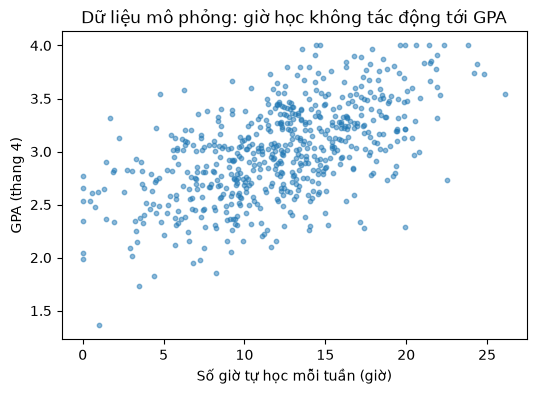

In [17]:
so_sinh_vien = 600
dong_luc = rng.normal(0, 1, size=so_sinh_vien)

gio_hoc = 12 + 4 * dong_luc + rng.normal(0, 3, size=so_sinh_vien)
gio_hoc = np.clip(gio_hoc, 0, None)
gpa = 3.0 + 0.35 * dong_luc + rng.normal(0, 0.3, size=so_sinh_vien)   # không có gio_hoc trong công thức
gpa = np.clip(gpa, 0, 4)

plt.figure(figsize=(6, 4))
plt.scatter(gio_hoc, gpa, s=10, alpha=0.5)
plt.xlabel("Số giờ tự học mỗi tuần (giờ)")
plt.ylabel("GPA (thang 4)")
plt.title("Dữ liệu mô phỏng: giờ học không tác động tới GPA")
plt.show()

Trên hình, sinh viên học nhiều giờ thường có GPA cao hơn. Nhìn đồ thị, rất dễ kết luận "học thêm thì GPA tăng". Nhưng ta biết chắc kết luận đó sai *trong mô phỏng này*, vì chính ta viết ra công thức và không cho giờ học vào công thức GPA. Mối liên hệ trên hình hoàn toàn do động lực tạo ra.

Với dữ liệu thật, ta không biết công thức. Đó là lý do một bảng quan sát chỉ cho phép nói về mối liên hệ.

<details><summary>Đáp án W01-R02</summary>

1. Bảng mô tả được mối liên hệ giữa giờ học và GPA trong 600 sinh viên này. Nếu cách chọn 600 sinh viên phù hợp, có thể cân nhắc tổng quát hóa mối liên hệ đó.
2. Câu "nếu một sinh viên học thêm 1 giờ thì sao" hỏi về kết quả khi *can thiệp* vào một người. Bảng chỉ cho biết những sinh viên *vốn đã* học nhiều hay ít khác nhau thế nào. Đó là câu hỏi nhân quả.
3. Năng lực nền, động lực, độ khó của ngành, số môn đăng ký, sức khỏe, việc làm thêm, sai lệch khi tự khai giờ học. Các yếu tố này có thể liên quan cùng lúc tới giờ học và GPA.
</details>

### 3.8 Gộp dữ liệu có thể đổi nghĩa của "trung bình"

> **W01-R03.** Một trung tâm dữ liệu ghi độ trễ mạng mỗi phút cho từng máy chủ; bảng gốc có dạng `server_id × time` với biến `latency_ms`. Sau đó nhóm vận hành tạo bảng mới, mỗi máy chủ một hàng, chứa `mean_latency_ms`.
>
> 1. Thông tin gì mất đi khi chuyển sang bảng đã gộp?
> 2. "Độ trễ trung bình" ở hai bảng có cùng ý nghĩa không?
> 3. Nếu vài máy chủ có 1.000 lần đo còn máy khác chỉ có 100 lần, trung bình của các trung bình máy chủ có nhất thiết bằng trung bình của tất cả lần đo gốc không?

**Dự đoán trước khi chạy:** với dữ liệu mô phỏng dưới đây, hai con số sẽ bằng nhau, hay số nào lớn hơn?

In [18]:
# Thử thay đổi: số lần đo và mức trễ điển hình của từng máy chủ
so_lan_do   = [1000, 1000, 100, 100, 100]
tre_dien_hinh = [20, 22, 60, 65, 70]        # ms; máy ít được đo lại chậm hơn

cac_bang = []
for i in range(len(so_lan_do)):
    tre = rng.normal(tre_dien_hinh[i], 5, size=so_lan_do[i])
    cac_bang.append(pd.DataFrame({"server_id": f"S{i+1}", "latency_ms": tre}))
log_goc = pd.concat(cac_bang, ignore_index=True)

bang_gop = log_goc.groupby("server_id")["latency_ms"].agg(["count", "mean"]).round(1)
print(bang_gop, "\n")
print("Trung bình trên mọi lần đo gốc     :", round(log_goc["latency_ms"].mean(), 1), "ms")
print("Trung bình của các trung bình máy chủ:", round(bang_gop["mean"].mean(), 1), "ms")

           count  mean
server_id             
S1          1000  19.9
S2          1000  22.1
S3           100  60.5
S4           100  65.4
S5           100  69.9 

Trung bình trên mọi lần đo gốc     : 26.7 ms
Trung bình của các trung bình máy chủ: 47.6 ms


Hai con số chênh nhau rất xa. Trung bình trên mọi lần đo trả lời câu "một lần đo ngẫu nhiên thường trễ bao nhiêu"; hai máy chủ nhanh có tới 2.000 lần đo nên kéo con số xuống. Trung bình của các trung bình trả lời câu "một máy chủ điển hình trễ bao nhiêu"; mỗi máy được tính một phiếu như nhau.

Không con số nào sai. Chúng trả lời hai câu hỏi khác nhau, và bảng gộp đã âm thầm đổi đơn vị quan sát từ *lần đo* sang *máy chủ*.

Thử đặt `so_lan_do` bằng nhau cho cả 5 máy và chạy lại. Hai con số có còn chênh không? Vì sao?

<details><summary>Đáp án W01-R03</summary>

1. Mất diễn biến theo thời gian, các đỉnh trễ bất thường, mức dao động bên trong mỗi máy chủ, và số lần đo của mỗi máy (trừ khi giữ lại cột `count`).
2. Không hẳn. Ở bảng gốc, trung bình được lấy trên các lần đo. Ở bảng gộp, mỗi hàng là một máy chủ, nên mọi phép tính tiếp theo coi mỗi máy là một đơn vị.
3. Không nhất thiết. Hai con số chỉ bằng nhau khi mọi máy có cùng số lần đo (hoặc khi các máy có cùng mức trễ).
</details>

---
## Phần 4. Đọc cấu trúc dữ liệu bằng pandas

Tuần này Python chỉ làm một việc: giúp nhìn cấu trúc bảng. Một cột là một `pandas.Series`; nhiều cột mô tả cùng một tập đơn vị quan sát ghép lại thành một `pandas.DataFrame`.

Bốn thao tác dùng nhiều nhất:

| Lệnh | Cho biết |
|---|---|
| `df.head()` | vài hàng đầu |
| `df.shape` | (số hàng, số cột) |
| `df.columns` | tên các cột |
| `df.dtypes` | kiểu mà phần mềm dùng để lưu mỗi cột |

Nhớ ý nghĩa là đủ, không cần thuộc cú pháp.

In [19]:
print("shape:", loan_demo.shape)
print("columns:", list(loan_demo.columns))
print()
print(loan_demo.dtypes)

shape: (50, 4)
columns: ['term', 'grade', 'state', 'interest_rate']

term             float64
grade                str
state                str
interest_rate    float64
dtype: object


Đọc kết quả theo ý nghĩa của dữ liệu, không theo dtype:

- `term` được lưu là `float64` (vì file gốc lưu số thập phân), nhưng thực chất là số tháng, chỉ nhận 36 hoặc 60: biến số rời rạc.
- `grade` và `state` được lưu là `object` (chuỗi ký tự; pandas 3.0 trở đi hiển thị `str`). Cả hai là biến phân loại, nhưng `grade` có thứ tự còn `state` thì không. `object` không phân biệt được điều đó.
- `interest_rate` là `float64`, và lần này dtype khớp với bản chất: biến số liên tục.

Ta có thể báo cho pandas biết ý nghĩa thật. Ô dưới khai báo `grade` là biến phân loại *có thứ tự*. Sau đó pandas hiểu được phép so sánh "hạng tốt hơn".

In [20]:
loan_typed = loan_demo.copy()
loan_typed["state"] = loan_typed["state"].astype("category")
loan_typed["grade"] = pd.Categorical(loan_typed["grade"],
                                     categories=["A", "B", "C", "D", "E", "F", "G"],
                                     ordered=True)
print(loan_typed.dtypes, "\n")
print("Số khoản vay hạng B trở lên (A hoặc B):", (loan_typed["grade"] <= "B").sum())

term              float64
grade            category
state            category
interest_rate     float64
dtype: object 

Số khoản vay hạng B trở lên (A hoặc B): 34


> **W01-PY01.** Một bảng quản lý sinh viên sau khi đọc vào pandas cho kết quả:
>
> ```
> shape: (1200, 6)
> ma_sinh_vien     int64
> muc_danh_gia     int64
> nganh_hoc       object
> ...
> ```
>
> 1. `shape: (1200, 6)` nói gì về bảng?
> 2. `ma_sinh_vien` có dtype `int64`. Có nên xem đây là biến số rời rạc không?
> 3. `muc_danh_gia` cũng là `int64`. Cần biết thêm gì để xếp loại nó?
> 4. Vì sao dtype có ích cho phần mềm nhưng không đủ để xác định loại biến thống kê?

<details><summary>Đáp án</summary>

1. Bảng có 1.200 hàng và 6 cột. Chỉ vậy thôi: chưa biết 1.200 hàng có phải 1.200 sinh viên khác nhau hay không.
2. Không. Mã sinh viên dùng để định danh, nên là biến phân loại danh nghĩa dù được lưu bằng số nguyên.
3. Cần biết thang đo nghĩa là gì. Nếu 1–5 là các mức đánh giá có thứ tự thì là phân loại thứ bậc; nếu là số lần vi phạm đếm được thì là biến số rời rạc.
4. dtype giúp máy chọn cách lưu và cách tính toán. Loại biến thống kê phụ thuộc vào việc đo cái gì và phép toán nào có nghĩa trên giá trị, và điều đó chỉ người hiểu dữ liệu mới biết.
</details>

---
## Phần 5. Tổng hợp

### 5.1 Tự thiết kế một bảng dữ liệu

> **W01-D01.** Một nhóm nghiên cứu muốn tìm hiểu nhiệt độ phòng có liên quan đến thời gian hoàn thành một tác vụ kỹ thuật hay không. Mỗi người có thể làm nhiều tác vụ và được đo ở nhiều buổi.
>
> Chưa có bảng mẫu. Hãy đề xuất một data frame tối thiểu:
> 1. Mỗi hàng là gì?
> 2. Biến kết quả là gì?
> 3. Biến giải thích chính là gì?
> 4. Cần những cột nào để biết một người được đo lặp lại?
> 5. Đề xuất ít nhất hai biến phụ giúp diễn giải kết quả.
> 6. Nếu câu hỏi đổi từ "có liên quan không?" thành "tăng nhiệt độ thì thời gian hoàn thành thay đổi bao nhiêu?", chỉ sửa bảng dữ liệu có đủ không?

Viết thử thiết kế của bạn vào ô code dưới (dạng tên cột), rồi mở đáp án để so.

In [21]:
# Điền tên cột bạn đề xuất, mỗi tên là một chuỗi
cot_de_xuat = ["...", "..."]
pd.DataFrame(columns=cot_de_xuat)

,...,...


<details><summary>Một phương án hợp lý</summary>

- Mỗi hàng: một *người × buổi × tác vụ*.
- Kết quả: `completion_time_s` (giây).
- Giải thích chính: `room_temperature_c`.
- Nhận diện đo lặp: `participant_id`, `session_id`, `task_id`.
- Biến phụ: độ khó tác vụ, thứ tự làm tác vụ trong buổi, kinh nghiệm của người làm, giờ trong ngày, độ ồn, thiết bị sử dụng.

Câu 6: không đủ. Chuyển từ câu hỏi về mối liên hệ sang câu hỏi nhân quả đòi hỏi thay đổi *cách tạo ra dữ liệu*, chẳng hạn chủ động điều chỉnh nhiệt độ phòng theo một kế hoạch so sánh được. Đổi tên cột hay thêm cột không làm dữ liệu quan sát trở thành dữ liệu thí nghiệm.
</details>

### 5.2 Cùng tên cột, khác nghĩa

> **W01-CH04.** Hai nhóm nghiên cứu đều có bảng với đúng ba cột `id`, `temperature_c`, `latency_ms`. Hãy nghĩ ra hai nghiên cứu sao cho `id` mang nghĩa khác nhau, mỗi hàng là một loại đơn vị khác nhau, và vì thế "trung bình `latency_ms`" được hiểu khác nhau. Không được đổi tên cột.

<details><summary>Một ví dụ</summary>

*Nghiên cứu 1, đơn vị là máy chủ.* `id` là mã máy chủ; mỗi hàng là một máy chủ sau một bài kiểm thử; `temperature_c` là nhiệt độ trung bình trong lúc kiểm thử; `latency_ms` là độ trễ trung bình của máy đó. Trung bình cột `latency_ms` là độ trễ của một máy chủ điển hình.

*Nghiên cứu 2, đơn vị là gói tin.* `id` là mã gói tin; mỗi hàng là một gói; `temperature_c` là nhiệt độ máy chủ khi gói được xử lý; `latency_ms` là độ trễ của chính gói đó. Trung bình cột `latency_ms` là độ trễ của một gói tin điển hình, và máy chủ nào xử lý nhiều gói sẽ chiếm tỉ trọng lớn hơn (giống ví dụ ở mục 3.8).
</details>

### 5.3 Bốn kiểu câu từ cùng một log

> **W01-CH05.** Log máy chủ có các cột `temperature_c`, `latency_ms`, `load`, `server_id`, `time`. Viết bốn câu: (1) một tóm tắt, (2) một câu về mối liên hệ giữa nhiệt độ và độ trễ, (3) một dự đoán cho lần chạy mới, (4) một khẳng định nhân quả về việc thay đổi nhiệt độ. Sau đó nêu bằng chứng cần thêm trước khi tin các câu mạnh hơn.

<details><summary>Một bộ câu hợp lệ</summary>

1. "Trong log tuần này, độ trễ trung vị là ... ms."
2. "Trong log tuần này, các thời điểm nhiệt độ cao thường đi kèm độ trễ cao hơn."
3. "Từ nhiệt độ và tải hiện tại, ta dự đoán độ trễ của lần chạy tiếp theo là ... ms."
4. "Nếu chủ động tăng nhiệt độ máy chủ thêm 5°C, độ trễ sẽ tăng."

Bằng chứng cần có tăng dần:

- Câu 1 cần phép đo và xử lý số liệu đáng tin.
- Câu 2 cần mô tả quan hệ cẩn thận; nếu muốn nói ra ngoài tuần này thì cần biết log được thu thập có đại diện không.
- Câu 3 cần kiểm tra dự đoán trên những lần chạy mà mô hình chưa thấy.
- Câu 4 cần một thiết kế tách được tác động của nhiệt độ khỏi các yếu tố khác, ví dụ tải: tải cao làm máy vừa nóng vừa chậm.
</details>

### 5.4 100.000 hàng có phải là $n = 100.000$?

> **W01-CH06.** Một công ty theo dõi 100 thiết bị, mỗi thiết bị đo 1.000 lần, nên bảng có đúng 100.000 hàng. Bác bỏ phát biểu: "Bảng có 100.000 hàng nên kích thước mẫu chắc chắn là $n = 100.000$."
> 1. Đơn vị nào đang được đo lặp?
> 2. Nêu một câu hỏi mà 100 thiết bị, chứ không phải 100.000 hàng, mới là số đơn vị độc lập quan trọng.
> 3. Vì sao số hàng vẫn là thông tin có ích, nhưng không đồng nghĩa với lượng thông tin độc lập?

Mô phỏng dưới giúp thấy vấn đề. Có 50 thiết bị loại A và 50 thiết bị loại B, và ta cố ý cho **hai loại hoàn toàn giống nhau**. Mỗi thiết bị có một mức nhiệt nền riêng (thiết bị này chạy nóng hơn thiết bị kia), cộng thêm dao động nhỏ giữa các lần đo.

Ta lặp lại toàn bộ nghiên cứu 300 lần, mỗi lần với 100 thiết bị mới, và ghi lại chênh lệch nhiệt độ trung bình giữa loại A và loại B. Để so sánh, ta cũng làm một thế giới giả tưởng trong đó 100.000 lần đo là 100.000 thiết bị khác nhau.

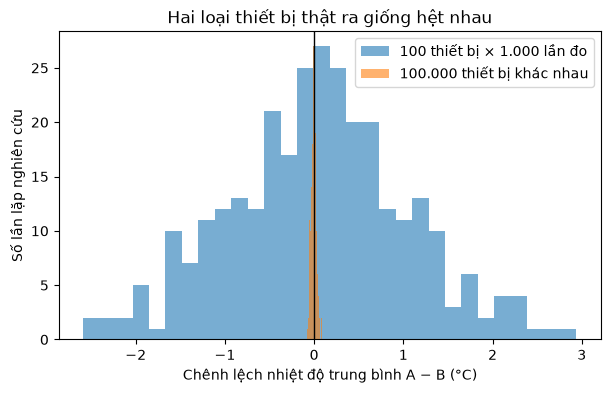

Độ rộng điển hình (SD) của chênh lệch:
  đo lặp  : 1.01 °C
  độc lập : 0.03 °C


In [22]:
# Thử thay đổi
so_thiet_bi_moi_loai = 50
so_lan_do_moi_thiet_bi = 1000
so_lan_lap_nghien_cuu = 300

chenh_lech_do_lap = []      # thực tế: 100 thiết bị, mỗi cái đo 1000 lần
chenh_lech_doc_lap = []     # giả tưởng: 100.000 thiết bị, mỗi cái đo 1 lần

for _ in range(so_lan_lap_nghien_cuu):
    # Thực tế
    nen_A = rng.normal(50, 5, size=so_thiet_bi_moi_loai)
    nen_B = rng.normal(50, 5, size=so_thiet_bi_moi_loai)
    do_A = np.repeat(nen_A, so_lan_do_moi_thiet_bi) + rng.normal(0, 1, size=so_thiet_bi_moi_loai * so_lan_do_moi_thiet_bi)
    do_B = np.repeat(nen_B, so_lan_do_moi_thiet_bi) + rng.normal(0, 1, size=so_thiet_bi_moi_loai * so_lan_do_moi_thiet_bi)
    chenh_lech_do_lap.append(do_A.mean() - do_B.mean())

    # Giả tưởng: mỗi hàng là một thiết bị riêng
    so_hang = so_thiet_bi_moi_loai * so_lan_do_moi_thiet_bi
    doc_lap_A = rng.normal(50, 5, size=so_hang) + rng.normal(0, 1, size=so_hang)
    doc_lap_B = rng.normal(50, 5, size=so_hang) + rng.normal(0, 1, size=so_hang)
    chenh_lech_doc_lap.append(doc_lap_A.mean() - doc_lap_B.mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(chenh_lech_do_lap, bins=30, alpha=0.6, label="100 thiết bị × 1.000 lần đo")
ax.hist(chenh_lech_doc_lap, bins=30, alpha=0.6, label="100.000 thiết bị khác nhau")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Chênh lệch nhiệt độ trung bình A − B (°C)")
ax.set_ylabel("Số lần lặp nghiên cứu")
ax.set_title("Hai loại thiết bị thật ra giống hệt nhau")
ax.legend()
plt.show()

print("Độ rộng điển hình (SD) của chênh lệch:")
print("  đo lặp  :", round(np.std(chenh_lech_do_lap), 3), "°C")
print("  độc lập :", round(np.std(chenh_lech_doc_lap), 3), "°C")

Histogram màu cam hẹp đến mức gần như dính vào vạch 0. Cả hai trường hợp đều có 100.000 hàng. Nhưng khi 100.000 hàng thật ra đến từ 100 thiết bị, chênh lệch giữa hai loại dao động rộng hơn rất nhiều giữa các lần lặp nghiên cứu: có lần lệch tới vài độ, dù hai loại giống hệt nhau. Lý do là 1.000 lần đo của cùng một thiết bị gần như lặp lại cùng một thông tin về mức nhiệt nền của nó. Đo thêm lần thứ 1.001 không cho biết gì mới về chuyện thiết bị đó nóng hay lạnh.

Nếu ai đó phân tích bảng như thể có 100.000 thiết bị độc lập, họ sẽ tưởng kết quả chắc chắn hơn nhiều so với thực tế. Tuần 09 sẽ đo mức dao động này bằng một đại lượng cụ thể.

Thử đổi `so_lan_do_moi_thiet_bi` từ 1000 xuống 10. Histogram màu xanh có hẹp đi đáng kể không? Còn nếu tăng `so_thiet_bi_moi_loai` lên 200?

<details><summary>Đáp án W01-CH06</summary>

1. Thiết bị. Mỗi thiết bị xuất hiện 1.000 lần, và các lần đo của cùng một thiết bị liên quan chặt với nhau.
2. "Thiết bị loại A có nhiệt độ trung bình khác thiết bị loại B không?" Ở đây đơn vị để so sánh là thiết bị, và ta chỉ có 100 thiết bị.
3. 100.000 lần đo vẫn rất có ích, ví dụ để mô tả dao động theo thời gian của từng thiết bị. Nhưng chúng không tạo ra 100.000 mẩu thông tin độc lập về khác biệt giữa các thiết bị. Khi viết $n$, luôn nói rõ đang đếm cái gì: số lần đo là 100.000, số thiết bị là 100.
</details>

### 5.5 Tình huống tổng hợp: `email50` và bộ lọc thư rác

Một nhóm muốn dùng đặc điểm của thư để hỗ trợ lọc thư rác và bắt đầu với `email50`.

In [23]:
email50[["spam", "cc", "image", "attach", "exclaim_mess", "number"]].head()

,spam,cc,image,attach,exclaim_mess,number
0,0,0,0.0,0.0,8.0,small
1,0,0,0.0,0.0,1.0,big
2,1,4,0.0,2.0,2.0,none
3,0,0,0.0,0.0,1.0,small
4,0,0,0.0,0.0,43.0,small


In [24]:
email50["spam"].value_counts()

spam
0    45
1     5
Name: count, dtype: int64

> **W01-CASE01.**
> 1. "Trong 50 thư hiện có, có 5 thư rác" là loại khẳng định nào?
> 2. Đoán một thư mới có phải thư rác không là loại nào?
> 3. "Thêm dấu chấm than sẽ làm thư bị xem là thư rác" là loại nào? `email50` có đủ để chứng minh không?
> 4. Đơn vị quan sát là gì?
> 5. Chọn ba biến và xếp loại.
> 6. Vì sao các cột trong DataFrame phải cùng mô tả 50 thư theo cùng một thứ tự hàng (index)?

<details><summary>Đáp án</summary>

1. Tóm tắt.
2. Dự đoán.
3. Khẳng định nhân quả. Dữ liệu quan sát như `email50` không đủ: thư rác có nhiều dấu chấm than có thể vì người viết thư rác vốn có phong cách đó, không phải vì dấu chấm than làm thư thành thư rác.
4. Một thư điện tử.
5. Ví dụ: `spam` phân loại danh nghĩa; `cc` số rời rạc; `number` phân loại thứ bậc.
6. Nếu một cột bị lệch thứ tự, một hàng sẽ ghép giá trị của nhiều thư khác nhau và mất nghĩa. Ô dưới cho thấy chuyện đó xảy ra dễ thế nào.
</details>

In [25]:
lech = email50[["spam", "exclaim_mess"]].copy()
lech["exclaim_mess"] = email50["exclaim_mess"].sort_values().values   # vô tình sắp xếp riêng một cột
print("Hai hàng đầu khi đúng thứ tự:")
print(email50[["spam", "exclaim_mess"]].head(2))
print("\nHai hàng đầu sau khi một cột bị sắp xếp riêng:")
print(lech.head(2))

Hai hàng đầu khi đúng thứ tự:
   spam  exclaim_mess
0     0           8.0
1     0           1.0

Hai hàng đầu sau khi một cột bị sắp xếp riêng:
   spam  exclaim_mess
0     0           0.0
1     0           0.0


Sau khi một cột bị sắp xếp riêng, hàng 0 ghép nhãn `spam` của thư này với số dấu chấm than của thư khác. Mọi phân tích trên bảng lệch này đều vô nghĩa, dù code chạy không báo lỗi.

---
## Tổng kết

**Câu hỏi cuối buổi (W01-Q05).** Một bạn mới nhận bảng dữ liệu và nhận xét: (1) "Cột này lưu kiểu số nguyên nên nó là biến số." (2) "Mỗi hàng luôn là một người." Sửa từng câu cho đúng. Sau đó: khi mở một bộ dữ liệu mới, bốn câu hỏi đầu tiên nên hỏi là gì?

<details><summary>Đáp án</summary>

1. Kiểu số nguyên chỉ là cách phần mềm lưu. Muốn biết biến số hay phân loại phải hiểu giá trị có nghĩa gì.
2. Mỗi hàng là một quan sát, nhưng đơn vị quan sát có thể là người, thư điện tử, khoản vay, cặp quốc gia–năm, lượt sinh viên–môn–học kỳ...

Bốn câu hỏi đầu tiên: Mỗi hàng là gì? Mỗi cột ghi lại điều gì? Dữ liệu được tạo ra như thế nào? Ta muốn dùng dữ liệu để đưa ra loại khẳng định nào?
</details>

**Những điều mang theo sau Tuần 01**

1. Bắt đầu từ câu hỏi. Câu hỏi quyết định cần đơn vị nào, biến nào, mức chi tiết nào.
2. Dữ liệu là sản phẩm của một quá trình: đo ai, đo thế nào, bao nhiêu lần, có can thiệp hay chỉ quan sát.
3. Một kết luận mạnh đến đâu phụ thuộc vào cách dữ liệu được tạo ra, không phụ thuộc vào số hàng. Tóm tắt khác tổng quát hóa; mối liên hệ khác dự đoán, và cả hai khác nhân quả.
4. Một hàng là một quan sát, nhưng chưa chắc là một đơn vị độc lập. Hãy tìm các phép đo lặp.
5. Gộp dữ liệu có thể làm mất thông tin và âm thầm đổi đơn vị quan sát.
6. Kiểu lưu trữ không quyết định loại biến. Một cột số có thể là mã định danh hoặc thang thứ bậc.

**Chuẩn bị cho Tuần 02.** Tuần sau chuyển từ câu hỏi "dữ liệu gồm những gì" sang "dữ liệu trông như thế nào". Hãy ôn lại biến phân loại và biến số, đơn vị quan sát và phép đo lặp. Khi đọc trước, tự hỏi: với mỗi loại biến, nên dùng bảng, con số hay biểu đồ nào để mô tả dữ liệu một cách trung thực?

---
*Nguồn: STAT 20 (UC Berkeley), bản dịch tiếng Việt, Chương 1; OpenIntro Statistics 4e, Chương 1 (email50, Seattle pets, bài 1.17); Introduction to Modern Statistics 2e, Chương 1 (loan50, MCU films, Palmer penguins). Dữ liệu mô phỏng ở mục 3.6, 3.7, 3.8, 5.4 do giảng viên tạo để minh họa, không phải số liệu thực.*